In [34]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

In [35]:

card=pd.read_csv(r"C:..\cleanData\clean_card.csv", sep=";")
card.head()

,card_id,disp_id,type,issued
0,1005,9285,classic,1993-11-07
1,104,588,classic,1994-01-19
2,747,4915,classic,1994-02-05
3,70,439,classic,1994-02-08
4,577,3687,classic,1994-02-15


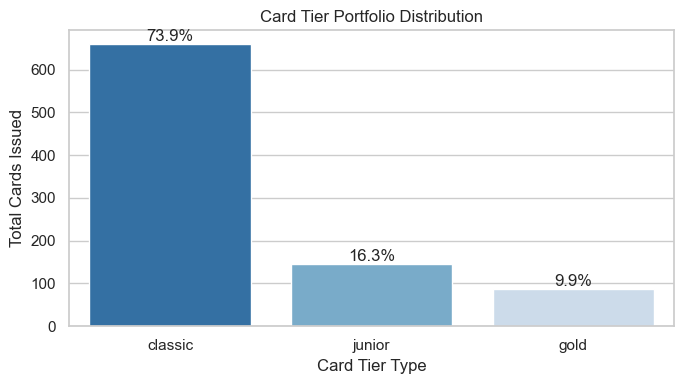

In [36]:
# 💳 Focused EDA & Feature Engineering Guide for `card` Table

# ---

## 1. High-Impact Exploratory Data Analysis (EDA)

# Since the `card` table contains credit/debit card issuances with temporal (`issued`), entity relation (`disp_id`), tier (`type`), and identity (`card_id`) features, the EDA should focus on adoption trends, portfolio tier distribution, and issuance velocity.

# ### A. Card Tier Distribution & Portfolio Composition
# Examines the proportion of standard versus premium card products (`classic`, `junior`, `gold`).

# ```python

plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=card,
    x="type",
    order=card["type"].value_counts().index,
    palette="Blues_r",
)
plt.title("Card Tier Portfolio Distribution")
plt.xlabel("Card Tier Type")
plt.ylabel("Total Cards Issued")

# Add percentage annotations
total = len(card)
for p in ax.patches:
  percentage = f"{100 * p.get_height() / total:.1f}%"
  ax.annotate(
      percentage,
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="bottom",
  )

plt.tight_layout()
plt.show()

In [37]:
# # Convert to datetime if not already done
# card["issued"] = pd.to_datetime(card["issued"])

# # Aggregate by month
# card_monthly = card.set_index("issued").resample("ME")["card_id"].count()

# plt.figure(figsize=(10, 4))
# card_monthly.plot(color="#1f77b4", linewidth=2)
# plt.title("Monthly Card Issuance Growth Rate")
# plt.xlabel("Issuance Date")
# plt.ylabel("New Cards Issued")
# plt.tight_layout()
# plt.show()

In [38]:
card.head()

,card_id,disp_id,type,issued
0,1005,9285,classic,1993-11-07
1,104,588,classic,1994-01-19
2,747,4915,classic,1994-02-05
3,70,439,classic,1994-02-08
4,577,3687,classic,1994-02-15


## oooooo

In [39]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# 1. Load datasets
loans = pd.read_csv('../cleanData/clean_loan.csv', sep=';')
cards = pd.read_csv('../cleanData/clean_card.csv', sep=';')
disp = pd.read_csv('../cleanData/clean_disp.csv', sep=';')

# 2. Standardize keys as strings
loans['account_id'] = loans['account_id'].astype(str)
loans['loan_id'] = loans['loan_id'].astype(str)
disp['account_id'] = disp['account_id'].astype(str)
disp['disp_id'] = disp['disp_id'].astype(str)
cards['card_id'] = cards['card_id'].astype(str)
cards['disp_id'] = cards['disp_id'].astype(str)

# 3. Parse loan grant date
loans['loan_date'] = pd.to_datetime(loans['date'])

# 4. Parse card issuance date (Czech bank format YYMMDD)
if 'issued' in cards.columns:
    cards['card_issued_date'] = pd.to_datetime(
        cards['issued'].astype(str).str[:6], 
        format='%y%m%d', 
        errors='coerce'
    )
elif 'date' in cards.columns:
    cards['card_issued_date'] = pd.to_datetime(cards['date'])

# 5. Bridge card to account via disposition (focus on primary OWNER cards)
disp_owner = disp[disp['type'].str.upper() == 'OWNER'][['disp_id', 'account_id']]
card_with_account = cards.merge(disp_owner, on='disp_id', how='inner')

# 6. Merge with loan records on account_id
loan_cards_raw = loans[['loan_id', 'account_id', 'loan_date', 'target']].merge(
    card_with_account[['card_id', 'account_id', 'type', 'card_issued_date']],
    on='account_id',
    how='inner'
)

# 7. CRITICAL ANTI-LEAKAGE FILTER:
# Keep cards ONLY if issued strictly BEFORE the loan was approved
pre_loan_cards = loan_cards_raw[
    loan_cards_raw['card_issued_date'] < loan_cards_raw['loan_date']
].copy()

# Days prior to loan issuance
pre_loan_cards['card_days_before_loan'] = (
    pre_loan_cards['loan_date'] - pre_loan_cards['card_issued_date']
).dt.days

print(f"Total loans in portfolio: {len(loans)}")
print(f"Total cards matching loan accounts (all-time): {len(loan_cards_raw)}")
print(f"Cards issued strictly BEFORE the loan: {len(pre_loan_cards)}")
print(f"Unique loans with a pre-existing card: {pre_loan_cards['loan_id'].nunique()}")

pre_loan_cards.head()

Total loans in portfolio: 682
Total cards matching loan accounts (all-time): 170
Cards issued strictly BEFORE the loan: 0
Unique loans with a pre-existing card: 0


,loan_id,account_id,loan_date,target,card_id,type,card_issued_date,card_days_before_loan


In [45]:
# -------------------------------------------------------------------------
# Isolate Borrowers with Cards Issued Strictly Before Loan Origination
# -------------------------------------------------------------------------

# 1. Standardize types and calculate issuance timing delta
loans['loan_date'] = pd.to_datetime(loans['date'])
cards['card_issued_date'] = pd.to_datetime(cards['issued'])

disp_owner = disp[disp['type'].astype(str).str.upper().str.strip() == 'OWNER'][['disp_id', 'account_id']]
card_owner = cards.merge(disp_owner, on='disp_id', how='inner')

merged = loans[['loan_id', 'account_id', 'loan_date', 'amount', 'duration', 'payments', 'target']].merge(
    card_owner[['card_id', 'account_id', 'type', 'card_issued_date']],
    on='account_id',
    how='inner'
)

merged['days_before_loan'] = (merged['loan_date'] - merged['card_issued_date']).dt.days

# 2. Filter strictly for cards issued BEFORE the loan (anti-leakage rule)
pre_loan_cardholders_df = merged[merged['days_before_loan'] > 0].copy()

# Sort by longest prior card relationship
pre_loan_cardholders_df.sort_values(by='days_before_loan', ascending=False, inplace=True)
pre_loan_cardholders_df.reset_index(drop=True, inplace=True)

# 3. Rename columns for clean presentation
presentation_cols = [
    'loan_id',
    'account_id',
    'card_id',
    'type',
    'card_issued_date',
    'loan_date',
    'days_before_loan',
    'amount',
    'duration',
    'payments',
    'target'
]

pre_loan_cardholders_df = pre_loan_cardholders_df[presentation_cols].rename(
    columns={
        'type': 'card_tier',
        'amount': 'loan_amount',
        'payments': 'monthly_payment'
    }
)

# 4. Summary metrics and display
print(f"Total borrowers with pre-existing cards: {len(pre_loan_cardholders_df)}")
print(f"Default rate among pre-loan cardholders: {(pre_loan_cardholders_df['target'].mean() * 100):.2f}%")
print(f"Good loans: {(pre_loan_cardholders_df['target'] == 0).sum()} | Defaults: {(pre_loan_cardholders_df['target'] == 1).sum()}\n")

# Display the complete dataset
pre_loan_cardholders_df

Total borrowers with pre-existing cards: 36
Default rate among pre-loan cardholders: 0.00%
Good loans: 36 | Defaults: 0



,loan_id,account_id,card_id,card_tier,card_issued_date,loan_date,days_before_loan,loan_amount,duration,monthly_payment,target
0,5582,2982,565,gold,1997-01-06,1998-04-17,466,41256.0,12,3438.0,0
1,7305,11359,1247,classic,1995-06-13,1996-08-06,420,54024.0,12,4502.0,0
2,5520,2699,511,junior,1997-08-06,1998-08-30,389,231168.0,48,4816.0,0
3,6607,7894,1014,classic,1996-11-02,1997-10-21,353,153144.0,36,4254.0,0
4,5428,2262,434,classic,1997-12-30,1998-12-02,337,230220.0,36,6395.0,0
5,5526,2725,517,classic,1998-01-09,1998-11-08,303,69624.0,36,1934.0,0
6,6932,9491,1115,junior,1997-10-03,1998-06-25,265,225504.0,48,4698.0,0
7,5377,2116,408,classic,1996-12-10,1997-08-04,237,92400.0,12,7700.0,0
8,5435,2279,436,classic,1997-10-09,1998-06-01,235,314688.0,48,6556.0,0
9,5015,226,45,classic,1997-12-05,1998-07-12,219,109344.0,12,9112.0,0
